# **SETUP**


This section imports all the libraries required for data manipulation, visualization, preprocessing, model building, and evaluation. Setting up the environment at the beginning ensures that all required tools are available throughout the project.

In [455]:
import numpy as np
import os
import pandas as pd
import seaborn as sns

# To plot pretty figures
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
mpl.rc('axes', labelsize=14)
mpl.rc('xtick', labelsize=12)
mpl.rc('ytick', labelsize=12)

# Where to save the figures
PROJECT_ROOT_DIR = "."
CHAPTER_ID = "Capstone_project"
IMAGES_PATH = os.path.join(PROJECT_ROOT_DIR, "images", CHAPTER_ID)
os.makedirs(IMAGES_PATH, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = os.path.join(IMAGES_PATH, fig_id + "." + fig_extension)
    print("Saving figure", fig_id)
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

# **Load Dataset**

##### Dataset Description

Two datasets are used in this project.

• The Japanese dataset contains historical customer information along with the PURCHASE column, which indicates whether a customer purchased a new car. This dataset is used to train and evaluate the classification model.

• The Indian dataset contains customer information without purchase labels. After training the model on Japanese customers, it will be used to predict potential customers in the Indian market.

In [458]:
jpn = pd.read_csv(r"D:\Machine Learning\Capstone project\JPN Data.xlsx - CN_Mobiles.csv")
ind = pd.read_csv(r"D:\Machine Learning\Capstone project\IN_Data.xlsx - IN_Mobiles.csv")

# **Data**

In [460]:
jpn.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
0,00001Q15YJ,50,M,"445,344",439,0
1,00003I71CQ,35,M,"107,634",283,0
2,00003N47FS,59,F,"502,787",390,1
3,00005H41DE,43,M,"585,664",475,0
4,00007E17UM,39,F,"705,723",497,1


In [461]:
ind.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,DT_MAINT
0,20710B05XL,54,M,"1,425,390",4/20/2018
1,89602T51HX,47,M,"1,678,954",6/8/2018
2,70190Z52IP,60,M,"931,624",7/31/2017
3,25623V15MU,55,F,"1,106,320",7/31/2017
4,36230I68CE,32,F,"748,465",1/27/2019


In [462]:
jpn.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          40000 non-null  object
 1   CURR_AGE    40000 non-null  int64 
 2   GENDER      40000 non-null  object
 3   ANN_INCOME  40000 non-null  object
 4   AGE_CAR     40000 non-null  int64 
 5   PURCHASE    40000 non-null  int64 
dtypes: int64(3), object(3)
memory usage: 1.8+ MB


In [463]:
ind.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   ID          70000 non-null  object
 1   CURR_AGE    70000 non-null  int64 
 2   GENDER      70000 non-null  object
 3   ANN_INCOME  70000 non-null  object
 4   DT_MAINT    70000 non-null  object
dtypes: int64(1), object(4)
memory usage: 2.7+ MB


In [464]:
jpn.describe()

,CURR_AGE,AGE_CAR,PURCHASE
count,40000.00000,40000.000000,40000.000000
mean,44.99745,359.080250,0.575775
std,11.82008,203.063724,0.494231
min,25.00000,1.000000,0.000000
25%,35.00000,235.000000,0.000000
50%,45.00000,331.000000,1.000000
75%,55.00000,444.000000,1.000000
max,65.00000,1020.000000,1.000000


In [465]:
jpn["PURCHASE"].value_counts()

PURCHASE
1    23031
0    16969
Name: count, dtype: int64

In [466]:
jpn["ANN_INCOME"] = (
    jpn["ANN_INCOME"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

In [467]:
ind["ANN_INCOME"] = (
    ind["ANN_INCOME"]
    .str.replace(",", "", regex=False)
    .astype(float)
)

# **Create Test Set**

##### Train-Test Split

The Japanese dataset is divided into training and testing sets.

The training set is used to explore the data and train the model, while the testing set is reserved for evaluating how well the model performs on unseen data. Keeping the test set separate helps provide an unbiased estimate of model performance.

In [470]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(
    jpn,
    test_size=0.2,
    random_state=42
)
len(train_set)

32000

In [471]:
len(test_set)

8000

In [472]:
test_set["GENDER"] = test_set["GENDER"].map({
    "M": 1,
    "F": 0
})

In [473]:
bins = [0, 200, 360, 500, float("inf")]
labels = [
    "<200",
    "200-360",
    "360-500",
    ">500"
]
test_set["AGE_CAR_CAT"] = pd.cut(
    test_set["AGE_CAR"],
    bins=bins,
    labels=labels
)

In [474]:
test_set.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE,AGE_CAR_CAT
32823,82254W78EQ,49,1,233039.0,266,0,200-360
16298,40498E53PN,26,0,212139.0,300,1,200-360
28505,71420G32JJ,39,1,207635.0,365,1,360-500
6689,16684A94JL,65,1,547246.0,240,0,200-360
26893,67382N89QQ,36,1,764880.0,359,1,200-360


# **Exploring Data**

##### Exploratory Data Analysis

Exploratory Data Analysis (EDA) is performed to understand the characteristics of the dataset, identify patterns, detect anomalies, and examine relationships between variables before building the machine learning model.

In [477]:
jpn_train = train_set.copy()

In [478]:
jpn_train.head()

,ID,CURR_AGE,GENDER,ANN_INCOME,AGE_CAR,PURCHASE
14307,35464D77PN,40,F,627611.0,272,0
17812,44429Q44HM,44,F,317235.0,215,1
11020,27376I51VK,64,F,304187.0,948,1
15158,37578T79JX,25,F,271464.0,334,1
24990,62420C76JJ,51,F,399349.0,344,0


In [479]:
jpn_train.shape

(32000, 6)

In [480]:
jpn_train.isnull().sum()

ID            0
CURR_AGE      0
GENDER        0
ANN_INCOME    0
AGE_CAR       0
PURCHASE      0
dtype: int64

In [481]:
jpn_train.duplicated().sum()

0

In [482]:
jpn_train["PURCHASE"].value_counts(normalize=True)

PURCHASE
1    0.574375
0    0.425625
Name: proportion, dtype: float64

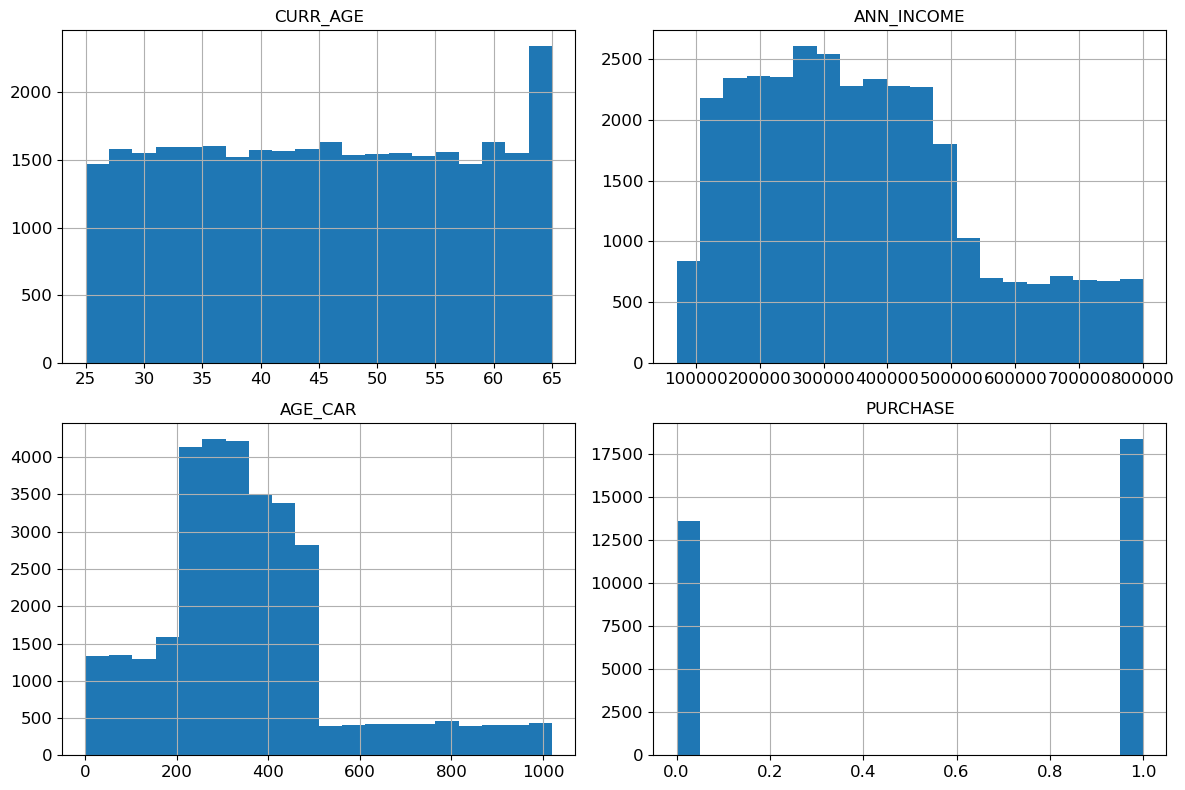

Saving figure Feature Distribution


<Figure size 640x480 with 0 Axes>

In [483]:
jpn_train.hist(
    figsize=(12,8),
    bins=20
)

plt.tight_layout()
plt.show()
save_fig("Feature Distribution")

### Observation

• Customer age is fairly distributed across different age groups.

• Annual income is positively skewed, with most customers belonging to the middle-income range.

• AGE_CAR is concentrated around the middle range, while fewer customers have very new or very old cars.

• PURCHASE contains two classes, indicating a binary classification problem.

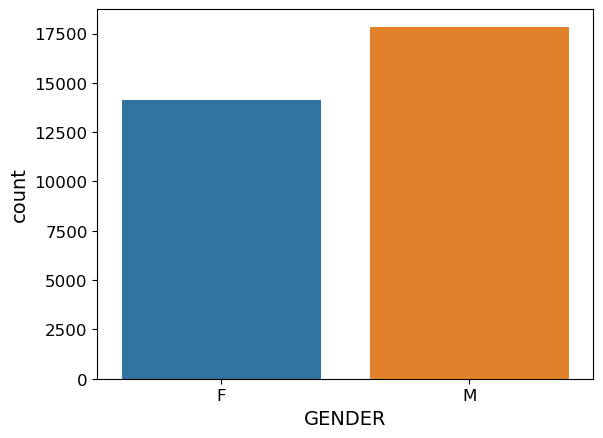

Saving figure Gender Distribution


<Figure size 640x480 with 0 Axes>

In [485]:
sns.countplot(
    data=jpn_train,
    x="GENDER"
)

plt.show()
save_fig("Gender Distribution")

### Observation

The dataset contains customers from both genders, with a slightly higher number of one category. Since the distribution is reasonably balanced, gender can be considered during model building without significant concern about class imbalance.

#### **Correlation**

In [488]:
corr_matrix = jpn_train.corr(numeric_only=True)

In [489]:
corr_matrix["PURCHASE"].sort_values(ascending=False)

PURCHASE      1.000000
AGE_CAR       0.320516
ANN_INCOME    0.164335
CURR_AGE     -0.005973
Name: PURCHASE, dtype: float64

Saving figure scatter_matrix_plot


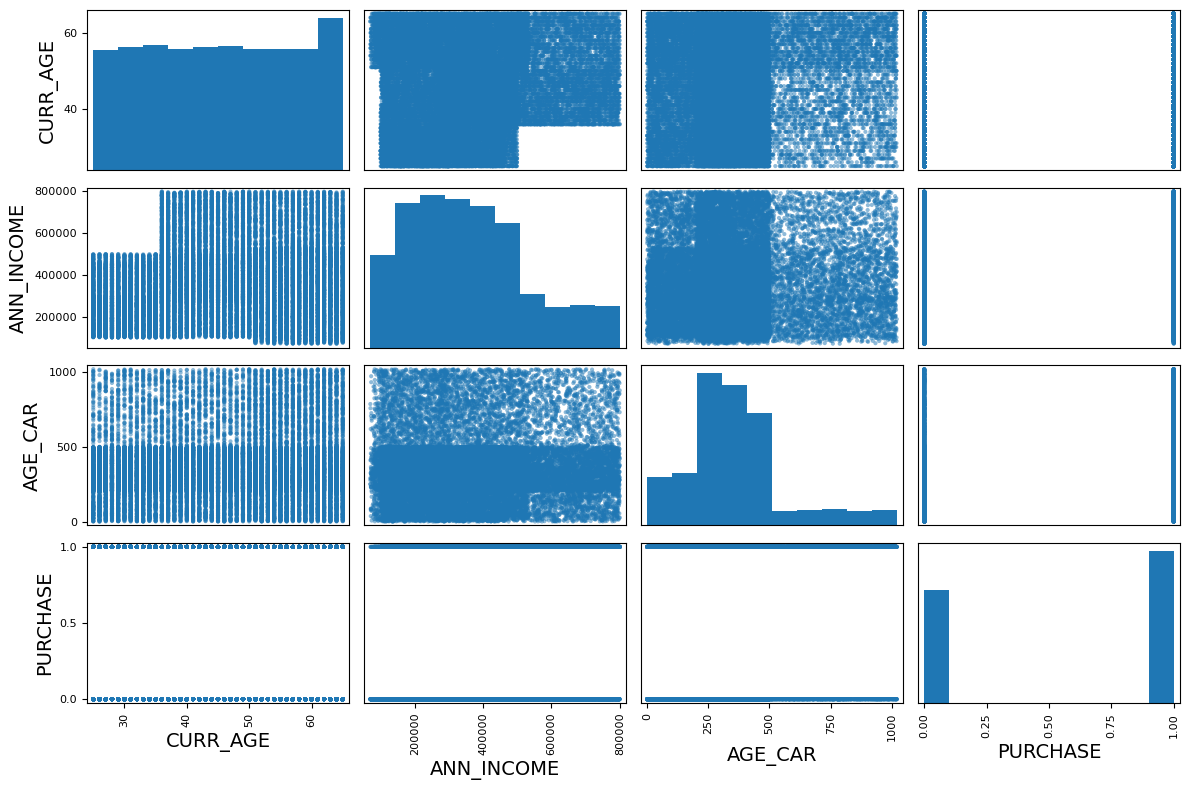

In [490]:
from pandas.plotting import scatter_matrix
attributes = [ 
    "CURR_AGE",
    "ANN_INCOME",
    "AGE_CAR",
    "PURCHASE"]
scatter_matrix(jpn_train[attributes], figsize=(12,8))
save_fig("scatter_matrix_plot")

### Observation

The scatter matrix shows that there are no strong linear relationships among the numerical variables. This suggests that customer purchasing behaviour depends on the combined effect of multiple variables rather than a single feature.

Saving figure AGE of car vs. PURCHASE


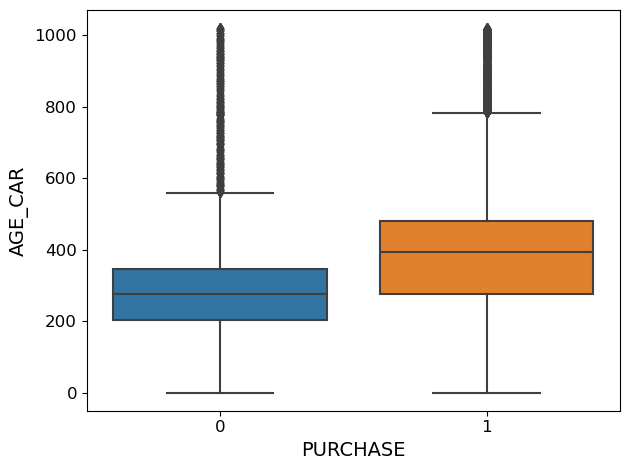

In [492]:
sns.boxplot(data=jpn_train,
            x="PURCHASE",
            y="AGE_CAR")
save_fig("AGE of car vs. PURCHASE")

Saving figure ANNUAL INCOME vs. PURCHASE


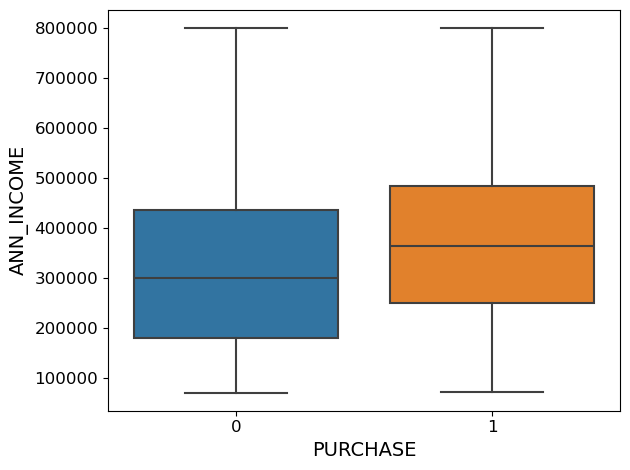

In [493]:
sns.boxplot(data=jpn_train,
            x="PURCHASE",
            y="ANN_INCOME")
save_fig("ANNUAL INCOME vs. PURCHASE")

### Observation

Customers who purchased a vehicle generally have higher annual income and slightly higher AGE_CAR values. However, there is considerable overlap between purchasers and non-purchasers, indicating that multiple features together influence purchasing decisions.

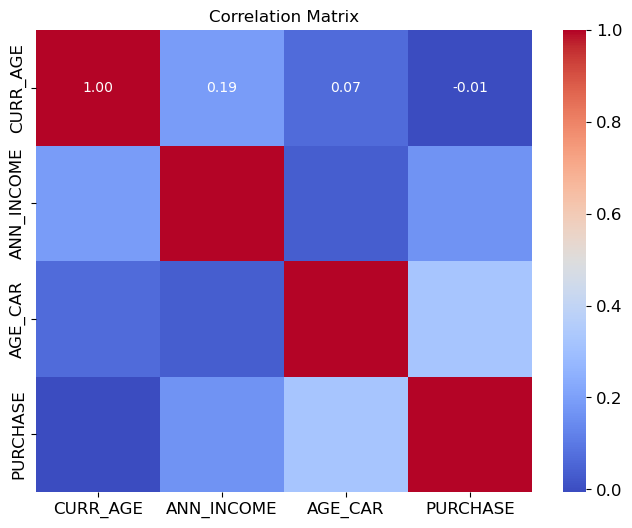

In [495]:
plt.figure(figsize=(8,6))

sns.heatmap(
    corr_matrix,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)

plt.title("Correlation Matrix")

plt.show()

### Observation

AGE_CAR has the highest positive correlation with PURCHASE, indicating that it is one of the strongest predictors in the dataset.

ANN_INCOME also shows a positive relationship with purchasing behaviour, whereas CURR_AGE has very little linear correlation with the target variable.

Although individual correlations are not very high, Logistic Regression can combine multiple features to make accurate predictions.

# **Feature Engineering**


Feature engineering involves creating new features that may improve the predictive performance of the model.

In this project, AGE_CAR is grouped into four categories to better represent different maintenance periods and simplify business interpretation.

In [499]:
car = jpn_train.copy()

In [500]:
bins = [0, 200, 360, 500, float("inf")]
labels = [
    "<200",
    "200-360",
    "360-500",
    ">500"
]
car["AGE_CAR_CAT"] = pd.cut(
    jpn_train["AGE_CAR"],
    bins=bins,
    labels=labels
)

In [501]:
car["AGE_CAR_CAT"].value_counts().sort_index()

AGE_CAR_CAT
<200        5203
200-360    13224
360-500     9337
>500        4236
Name: count, dtype: int64

C:\Users\cp\anaconda3\Lib\site-packages\seaborn\categorical.py:641: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  grouped_vals = vals.groupby(grouper)


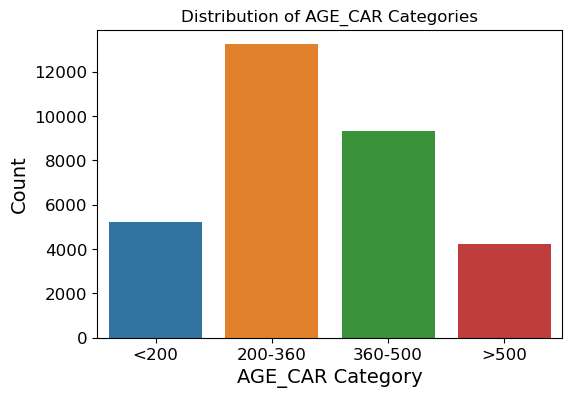

In [502]:
plt.figure(figsize=(6,4))

sns.countplot(
    data=car,
    x="AGE_CAR_CAT",
    order = [
    "<200",
    "200-360",
    "360-500",
    ">500"
]
)

plt.title("Distribution of AGE_CAR Categories")

plt.xlabel("AGE_CAR Category")

plt.ylabel("Count")

plt.show()

### Observation

Most customers belong to the middle AGE_CAR categories, while relatively fewer customers fall into the extreme groups. These categories may help capture purchasing patterns more effectively than using only the raw numerical values.

In [504]:
# Indian DT_MAINT TO AGE_CAR
analysis_date = pd.Timestamp("2019-07-01")

ind["DT_MAINT"] = pd.to_datetime(ind["DT_MAINT"])

ind["AGE_CAR"] = (
    analysis_date - ind["DT_MAINT"]
).dt.days

In [505]:
ind["AGE_CAR_CAT"] = pd.cut(
    ind["AGE_CAR"],
    bins=bins,
    labels=labels
)

In [506]:
ind["AGE_CAR_CAT"].value_counts().sort_index()

AGE_CAR_CAT
<200       18581
200-360    18909
360-500    18691
>500       13819
Name: count, dtype: int64

# **Data Preparation**


Before training the model, the data must be prepared for machine learning.

Numerical features are standardized to place them on a similar scale, while categorical features are encoded into numerical format so that they can be processed by the Logistic Regression algorithm.

In [509]:
X = car.drop(["ID", "PURCHASE"], axis=1)

y = car["PURCHASE"].copy()

In [510]:
car.dtypes

ID               object
CURR_AGE          int64
GENDER           object
ANN_INCOME      float64
AGE_CAR           int64
PURCHASE          int64
AGE_CAR_CAT    category
dtype: object

In [511]:
num_attribs = [
    "CURR_AGE",
    "ANN_INCOME",
    "AGE_CAR"
]

cat_attribs = [
    "GENDER",
    "AGE_CAR_CAT"
]

## Preprocessing Pipeline

A preprocessing pipeline is used to automate all data preparation steps.

Using a pipeline ensures that identical preprocessing is applied to the training data, testing data, and the Indian dataset, reducing the chances of data leakage and making the workflow reproducible.

In [513]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

In [514]:
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

In [515]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_attribs),
    ("cat", cat_pipeline, cat_attribs)
])

# **Model Training**

In [517]:
X_prepared = preprocessor.fit_transform(X)

## Model Building

Logistic Regression is selected because the target variable (PURCHASE) is binary.

The algorithm predicts the probability that a customer will purchase a new vehicle based on demographic and vehicle-related information. It is widely used because it is simple, interpretable, and performs well for binary classification tasks.

In [519]:
from sklearn.linear_model import LogisticRegression

log_reg = LogisticRegression(
    max_iter=1000,
    random_state=42
)

log_reg.fit(X_prepared, y)

LogisticRegression(max_iter=1000, random_state=42)

In [520]:
feature_names = preprocessor.get_feature_names_out()

coef_df = pd.DataFrame({
    "Feature": feature_names,
    "Coefficient": log_reg.coef_[0]
})

coef_df.sort_values(by="Coefficient", ascending=False)

,Feature,Coefficient
8,cat__AGE_CAR_CAT_>500,1.155478
6,cat__AGE_CAR_CAT_360-500,0.868442
1,num__ANN_INCOME,0.428061
4,cat__GENDER_M,0.250594
3,cat__GENDER_F,0.046385
2,num__AGE_CAR,0.045243
0,num__CURR_AGE,-0.124061
5,cat__AGE_CAR_CAT_200-360,-0.767312
7,cat__AGE_CAR_CAT_<200,-0.959629


## Business Interpretation of Model Coefficients

Positive coefficients increase the likelihood that a customer will purchase a new vehicle.

Negative coefficients decrease the likelihood of purchase.

Features with larger coefficient magnitudes have a stronger influence on the model's prediction.

These coefficients help ABG Motors understand which customer characteristics are associated with higher purchasing probability and can support future marketing decisions.

In [522]:
X_test = test_set.drop(["ID", "PURCHASE"], axis=1)
y_test = test_set["PURCHASE"].copy()

X_test_prepared = preprocessor.transform(X_test)

In [523]:
y_pred = log_reg.predict(X_test_prepared)

# **Model Evaluation**

#### **Accuracy**


Accuracy measures the percentage of correctly classified customers. A higher accuracy indicates better predictive performance, although it should be interpreted together with other evaluation metrics.

In [527]:
from sklearn.metrics import accuracy_score

y_pred = log_reg.predict(X_test_prepared)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.687875


#### **Confusion Matrix**


The confusion matrix provides a detailed breakdown of correct and incorrect predictions. It shows how many customers were correctly classified as purchasers and non-purchasers, along with the model's classification errors.

[[2481  868]
 [1629 3022]]


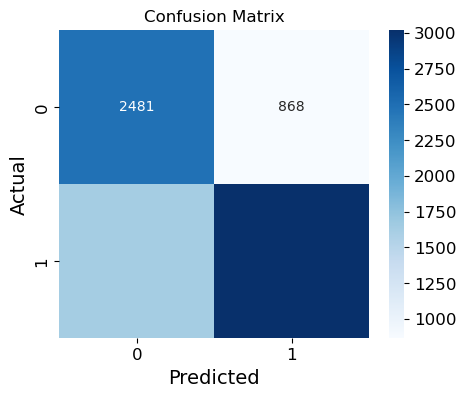

In [529]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)
print(cm)
plt.figure(figsize=(5,4))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

#### **Classification Report**

Precision measures how many predicted purchasers actually purchased.

Recall measures how many actual purchasers were identified.

The F1-score provides a balance between precision and recall.

Together these metrics provide a more comprehensive evaluation than accuracy alone.

In [531]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.60      0.74      0.67      3349
           1       0.78      0.65      0.71      4651

    accuracy                           0.69      8000
   macro avg       0.69      0.70      0.69      8000
weighted avg       0.70      0.69      0.69      8000



#### **ROC-AUC**

In [533]:
from sklearn.metrics import roc_auc_score

y_prob = log_reg.predict_proba(X_test_prepared)[:,1]

print("ROC AUC:", roc_auc_score(y_test, y_prob))

ROC AUC: 0.7616166819645794


#### **ROC Curve**

The ROC curve illustrates the trade-off between the true positive rate and false positive rate at different classification thresholds.

The AUC score summarizes this performance. A value closer to 1 indicates excellent classification ability.

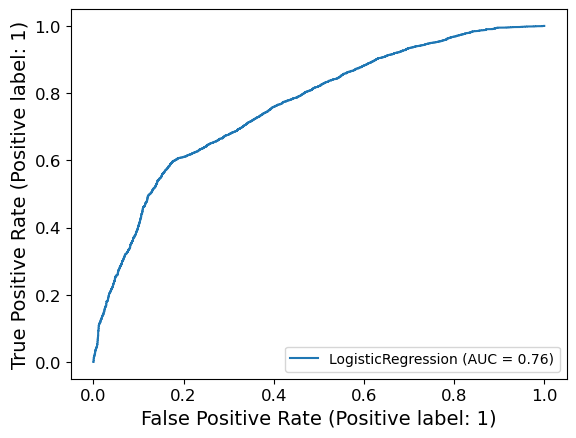

In [535]:
from sklearn.metrics import RocCurveDisplay

RocCurveDisplay.from_estimator(
    log_reg,
    X_test_prepared,
    y_test
)

plt.show()

# **Final Prediction**
#### Prediction on Indian Dataset

After validating the model on Japanese customer data, the trained model is applied to the Indian dataset to identify customers who are likely to purchase a new vehicle.

These predictions help estimate the potential market size before entering India.

In [537]:
X_ind = ind.drop("ID", axis=1)

X_ind_prepared = preprocessor.transform(X_ind)

ind["Predicted_Purchase"] = log_reg.predict(X_ind_prepared)

In [538]:
buyers = ind["Predicted_Purchase"].sum()

print("Predicted Buyers:", buyers)

Predicted Buyers: 67309


# Business Recommendation

The trained Logistic Regression model was successfully developed using historical customer data from Japan and evaluated using unseen test data.

The model was then applied to the Indian customer dataset to estimate the number of potential buyers.

Based on the predicted number of customers and the evaluation metrics, the model provides a data-driven estimate of market demand. This analysis can assist ABG Motors in deciding whether expanding into the Indian market is likely to be commercially beneficial.

Although the model provides valuable insights, additional business factors such as competition, pricing strategy, and regional customer preferences should also be considered before making the final market entry decision.